In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Etapas de un Problema de Machine Learning

* **Definir el Problema:** Que se pretende predecir? o Que datos son necesarios conseguir?
* **Explorar y Entender:** Entender los Datos para crear nuestro proyecto
* **Metrica de Exito:** Definir una metrica apropiada para cuantificar como de buenos son los resultados.
* **Preparar la estrategia para evaluar el modelo:** Separar el dataset en un conjunto de datos de entrenamiento (train), otro de prueba (test) y otro de validacion (validacion cruzada). Es muy importante asegurar que ninguna informacion del conjunto de datos del test participe en el proceso de entrenamiento.
* **Preprocesamiento de Datos:** Aplicar las transformaciones necesarias para que los datos puedan ser interpretados por el algoritmo de machine learning
* **Ajustar el Primer Modelo capaz de superar los resultados:** Por ejemplo en casos de clasificacion, como superar la clase mayoritaria (moda). En los regresion, la media de la variable respuesta.
Gradualmente, mejorar el modelo incorporando (nuevas variables) u optimizando los parametros por default.
* **Evaluar la capacidad del modelo final:** Con el conjunto de datos del test tener una estimacion de la capacidad que tiene nuestro modelo cuando predice valores nuevos.
* **Entrenar el modelo final:** con todos los datos disponibles para ingresarlos en una App

### Importar e Instalar Paquetes ##

In [12]:
pip install fitter

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from matplotlib import style
import matplotlib.ticker as ticker

from fitter  import Fitter, get_common_distributions


### Carga de Datos

In [14]:
datos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/SaratogaHouses.csv')

datos.columns = ['precio', 'metros_totales','antiguedad','precio_terreno','metros_habitables', 'universitarios','dormitorios','chimenea','banios',
                'habitaciones','calefaccion','consumo_calefaccion','desague','vista_lago','nueva_construccion','aire_acondicionado']

datos.head()

,precio,metros_totales,antiguedad,precio_terreno,metros_habitables,universitarios,dormitorios,chimenea,banios,habitaciones,calefaccion,consumo_calefaccion,desague,vista_lago,nueva_construccion,aire_acondicionado
0,132500,0.09,42,50000,906,35,2,1,1.0,5,electric,electric,septic,No,No,No
1,181115,0.92,0,22300,1953,51,3,0,2.5,6,hot water/steam,gas,septic,No,No,No
2,109000,0.19,133,7300,1944,51,4,1,1.0,8,hot water/steam,gas,public/commercial,No,No,No
3,155000,0.41,13,18700,1944,51,3,1,1.5,5,hot air,gas,septic,No,No,No
4,86060,0.11,0,15000,840,51,2,0,1.0,3,hot air,gas,public/commercial,No,Yes,Yes


### Analisis Exploratorio de los Datos

Antes de entrenar un modelo predictivo o inclusive antes de realizar cualquier calculo con nuevo conjunto de datos, es **muy importante** realizar una exploracion descriptiva de los mismos. Este proceso permite entender mejor que informacion contiene cada variable, asi tambien como detectar posibles errores.

 Algunos frecuentes son:

1. Que una columna se haya almacenado con el tipo de datos incorrecto: una variable numerica esta siendo reconocida como texto o viceversa.
2. Que una variable contenga valores que no tienen sentido: Por ejemplo, indicar que una vivienda tiene un valor de 0 o un espacio en blanco.
3. Que por error en una variable numerica se haya insertado texto.
4. Como se distribuyen los datos
5. Valores Atipicos
6. Correlacion entre variables


In [15]:
# Tipo de Datos contiene cada columna

datos.dtypes

,0
precio,int64
metros_totales,float64
antiguedad,int64
precio_terreno,int64
metros_habitables,int64
universitarios,int64
dormitorios,int64
chimenea,int64
banios,float64
habitaciones,int64


In [16]:
# Cantidad de Observaciones y variables

datos.shape

(1728, 16)

In [17]:
#Numero de Valores Faltantes o Vacios

datos.isnull().sum().sort_values(ascending=False)

,0
precio,0
metros_totales,0
antiguedad,0
precio_terreno,0
metros_habitables,0
universitarios,0
dormitorios,0
chimenea,0
banios,0
habitaciones,0


### Analizar la Variable  Respuesta

In [18]:
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

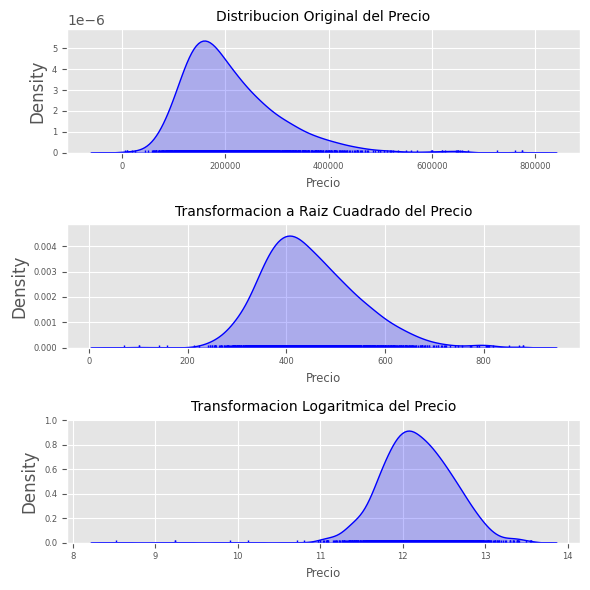

In [19]:
fig, axes = plt.subplots(nrows = 3, ncols= 1,figsize=(6, 6))

sns.distplot(
    datos['precio'],
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[0])

axes[0].set_title('Distribucion Original del Precio', fontsize = 'medium')
axes[0].set_xlabel('Precio', fontsize = 'small')
axes[0].tick_params(labelsize = 6)

###############################################################################

sns.distplot(
    np.sqrt(datos['precio']), ##
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[1])

axes[1].set_title('Transformacion a Raiz Cuadrado del Precio', fontsize = 'medium') ##
axes[1].set_xlabel('Precio', fontsize = 'small')
axes[1].tick_params(labelsize = 6)

###############################################################################

sns.distplot(
    np.log(datos['precio']), ##
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[2])

axes[2].set_title('Transformacion Logaritmica del Precio', fontsize = 'medium') ##
axes[2].set_xlabel('Precio', fontsize = 'small')
axes[2].tick_params(labelsize = 6)


fig.tight_layout()
plt.show()

El siguiente permite identificar a que distribucion se ajustan mejor los datos, se realiza por medio de fitter. Este paquete permite ajustar a cualquiera 115 distribuciones que existen en python.

1. **AIC = Criterio de Informacion Akaile**
2. **BIC = Criterio de Informacion Bayesiana**
3. **DIC = Criterio de Informacion Devianza**

En algunos modelos de Machine Learning y aprendizaje estadistico requieren que la variable respuesta se distribuya de una forma determinada. Por ejemplo, para los modelos de regresion Lineal, la distribucion tiene que ser normal. Para los modelos lineales Generalizados (GLM), la distribucion tiene que ser exponencial.

In [20]:
#Obtener todas las distribuciones mas comunes del paquete fitter

todas_las_distribuciones = get_common_distributions()

#Crear el objeto de Tiffet con todas las distribuciones

fitter = Fitter(datos.precio, distributions= todas_las_distribuciones)

#Ajustar los datos

fitter.fit()

#Mostrar el resumen de las N mejores distribuciones

resultados = fitter.summary(Nbest =  len(todas_las_distribuciones), plot = False)

#Mostrar las mejores 5 distribuciones segun el AIC (entre menor valor mejor es el ajuste)
mejores_distribuciones = resultados.sort_values(by = 'aic').head(5)

mejores_distribuciones


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
uniform,3.155020e-10,2714.829159,2725.738599,inf,0.471313,0.000000e+00
powerlaw,3.132284e-10,2728.809479,2745.173639,inf,0.344929,3.981254e-184
expon,2.915346e-10,2824.103160,2835.012600,inf,0.316530,2.028906e-154
cauchy,5.221450e-11,2956.669693,2967.579133,inf,0.121728,9.001774e-23
lognorm,1.682826e-11,3039.086368,3055.450528,inf,0.034578,3.134909e-02


In [21]:
# Estadistica Descriptiva de las variables numericas

datos.select_dtypes(include = np.number).describe()

,precio,metros_totales,antiguedad,precio_terreno,metros_habitables,universitarios,dormitorios,chimenea,banios,habitaciones
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,211966.705440,0.500214,27.916088,34557.187500,1754.975694,55.567708,3.154514,0.601852,1.900174,7.041667
std,98441.391015,0.698680,29.209988,35021.168056,619.935553,10.333581,0.817351,0.556102,0.658352,2.316453
min,5000.000000,0.000000,0.000000,200.000000,616.000000,20.000000,1.000000,0.000000,0.000000,2.000000
25%,145000.000000,0.170000,13.000000,15100.000000,1300.000000,52.000000,3.000000,0.000000,1.500000,5.000000
50%,189900.000000,0.370000,19.000000,25000.000000,1634.500000,57.000000,3.000000,1.000000,2.000000,7.000000
75%,259000.000000,0.540000,34.000000,40200.000000,2137.750000,64.000000,4.000000,1.000000,2.500000,8.250000
max,775000.000000,12.200000,225.000000,412600.000000,5228.000000,82.000000,7.000000,4.000000,4.500000,12.000000


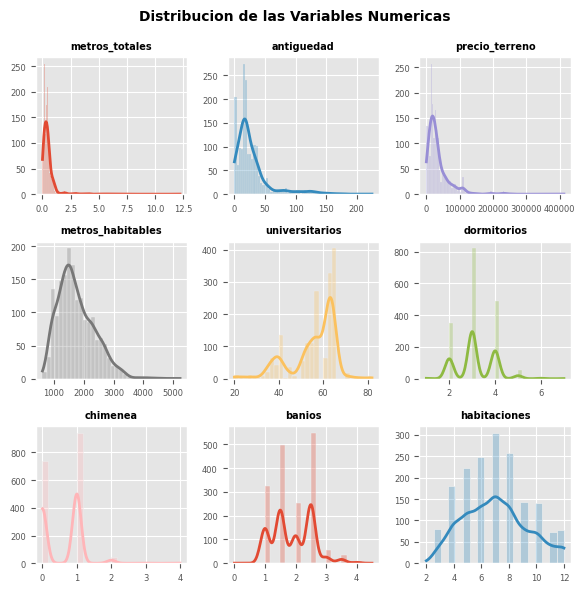

In [22]:
#Grafica de Distribucion para cada variable numerica

fig,axes=plt.subplots(nrows=3,ncols=3,figsize=(6,6))
axes=axes.flat
columnas_numericas=datos.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('precio')

for i,columna in enumerate(columnas_numericas):
  sns.histplot(
    data=datos,
    x=columna,
    stat='count',
    kde= True,
    color=list(plt.rcParams['axes.prop_cycle']*2)[i]['color'],
    line_kws={'linewidth':2},
    alpha=0.3,
    ax=axes[i])

  axes[i].set_title(columna,fontsize=7,fontweight='bold')
  axes[i].tick_params(labelsize=6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')


fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribucion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()

In [23]:
#Observar los valores de una variable numerica - categorica

datos.chimenea.value_counts()

,count
chimenea,
1,942
0,740
2,42
4,2
3,2


In [24]:
#Convertir la variable chimenea en cualitativa (string)

datos.chimenea=datos.chimenea.astype(str)

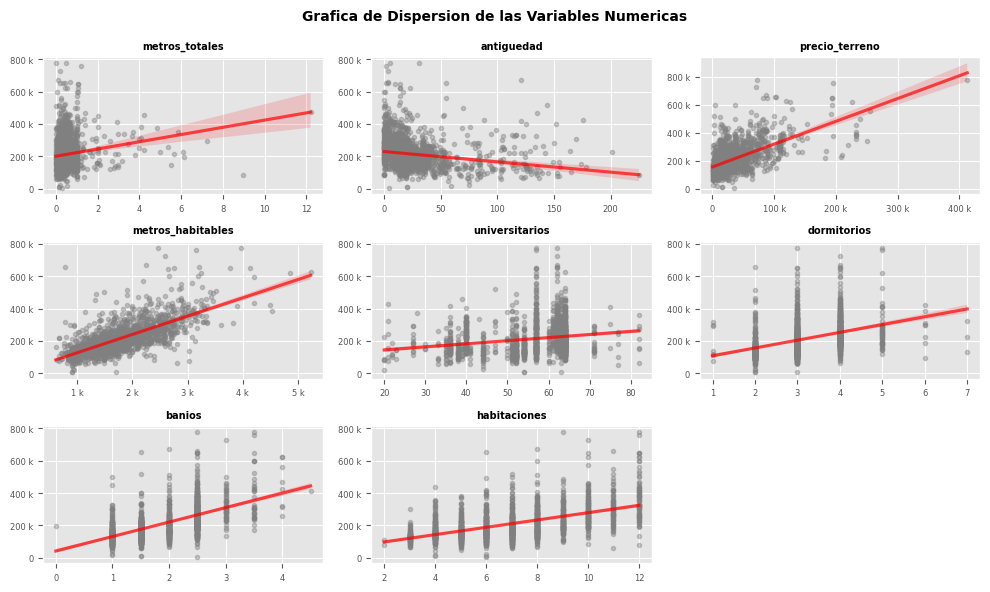

In [25]:
#Grafica de Dispersion para cada variable numerica y su relacion con la variable dependiente

fig,axes=plt.subplots(nrows=3,ncols=3,figsize=(10,6))
axes=axes.flat
columnas_numericas=datos.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('precio')

for i,columna in enumerate(columnas_numericas):
  sns.regplot(
    data=datos,
    x=datos[columna],
    y='precio',
    color = 'gray',
    marker = '.',
    scatter_kws= {'alpha': 0.4},
    line_kws = {'color':'red', 'alpha':0.7},
    ax = axes[i])

  axes[i].set_title(columna,fontsize=7,fontweight='bold')
  axes[i].tick_params(labelsize=6)
  axes[i].yaxis.set_major_formatter(ticker.EngFormatter())
  axes[i].xaxis.set_major_formatter(ticker.EngFormatter())
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

for i in [8]:
  fig.delaxes(axes[i])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Grafica de Dispersion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()


### Correlacion Variables Numericas

In [26]:
# Correlacion entre Variables Numericas

def matriz_correlacion(corr_mat):
  """ Funcion para convertir una matrix de correlacion a un formato tipo DataFrame """
  corr_mat=corr_mat.stack().reset_index()
  corr_mat.columns=['variable_1','variable_2','correlacion']
  corr_mat= corr_mat.loc[corr_mat['variable_1']!=corr_mat['variable_2'],:]
  corr_mat['Absoluto']=np.abs(corr_mat['correlacion'])
  corr_mat=corr_mat.sort_values('Absoluto',ascending=False)
  return corr_mat


corr_matrix = datos.select_dtypes(include = np.number).corr(method = 'pearson')
matriz_correlacion(corr_matrix).head(10)

,variable_1,variable_2,correlacion,Absoluto
44,metros_habitables,habitaciones,0.733666,0.733666
76,habitaciones,metros_habitables,0.733666,0.733666
67,banios,metros_habitables,0.718564,0.718564
43,metros_habitables,banios,0.718564,0.718564
36,metros_habitables,precio,0.712390,0.712390
4,precio,metros_habitables,0.712390,0.712390
78,habitaciones,dormitorios,0.671863,0.671863
62,dormitorios,habitaciones,0.671863,0.671863
42,metros_habitables,dormitorios,0.656196,0.656196
58,dormitorios,metros_habitables,0.656196,0.656196


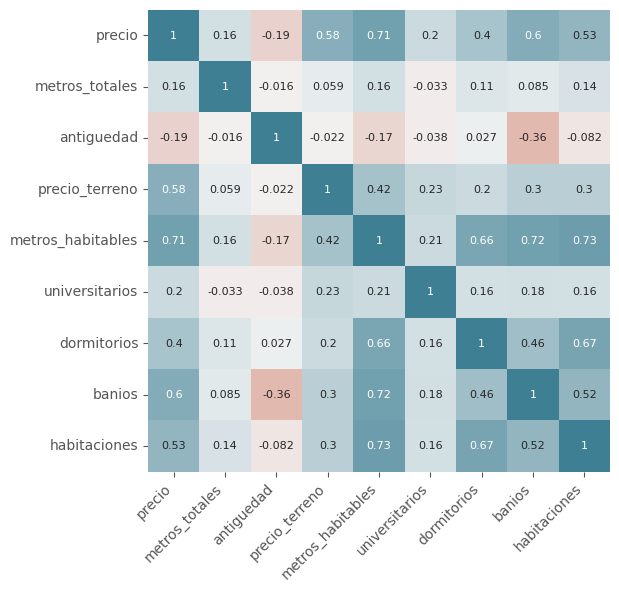

In [27]:
##HeatMap de Correlaciones

fig, axes = plt.subplots(nrows = 1, ncols =1, figsize = (6,6))

sns.heatmap(
    corr_matrix,
    cmap = sns.diverging_palette(20,220, n = 200),
    square = True,
    annot = True,
    center = 0,
    vmin = -1,
    vmax = 1,
    annot_kws = {'fontsize':8},
    cbar = False,
    ax = axes)

axes.set_xticklabels(axes.get_xticklabels(), rotation = 45, horizontalalignment = 'right')

plt.show()

### Variables Cualitativas

In [28]:
#Seleccionar las variables cualitativas

datos.select_dtypes(include = 'object')

,chimenea,calefaccion,consumo_calefaccion,desague,vista_lago,nueva_construccion,aire_acondicionado
0,1,electric,electric,septic,No,No,No
1,0,hot water/steam,gas,septic,No,No,No
2,1,hot water/steam,gas,public/commercial,No,No,No
3,1,hot air,gas,septic,No,No,No
4,0,hot air,gas,public/commercial,No,Yes,Yes
...,...,...,...,...,...,...,...
1723,1,hot water/steam,gas,public/commercial,No,No,No
1724,1,hot water/steam,gas,public/commercial,No,No,No
1725,0,hot air,gas,public/commercial,No,No,No
1726,1,hot air,gas,public/commercial,No,No,No


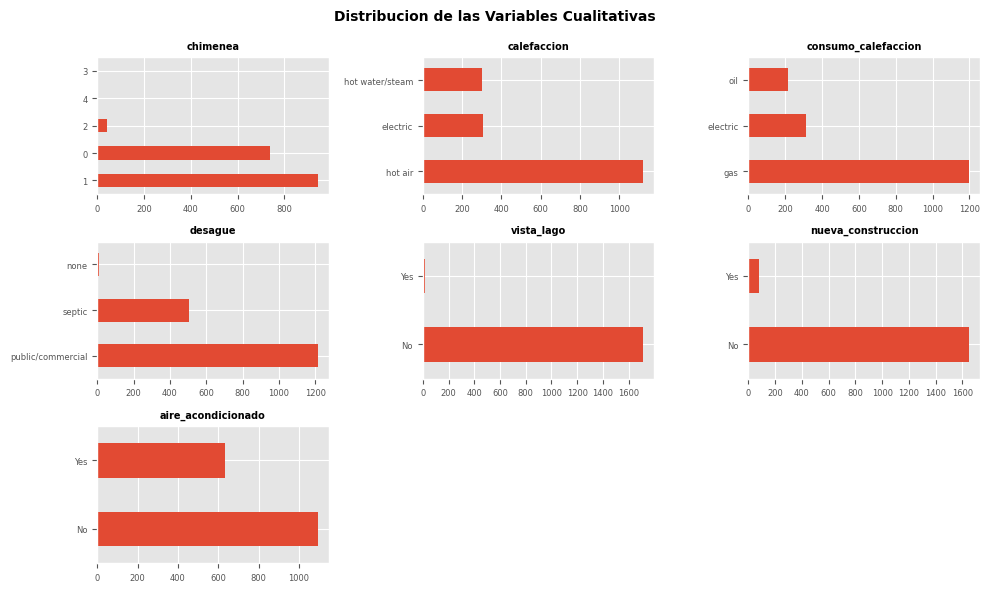

In [29]:
#Grafico para cada variable cualitativa

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (10,6))
axes = axes.flat
columnas_cualitativas = datos.select_dtypes(include = 'object').columns

for i, columna in enumerate(columnas_cualitativas):
  datos[columna].value_counts().plot(
      kind = 'barh',
      ax = axes[i])
  axes[i].set_title(columna, fontsize = 7, fontweight = 'bold')
  axes[i].tick_params(labelsize = 6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

for i in [7,8]:
  fig.delaxes(axes[i])

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Distribucion de las Variables Cualitativas', fontsize = 'medium', fontweight = 'bold')
plt.show()


Debemos de revisar en variables cualitativas los niveles de observaciones en comparacion con otros niveles de la misma variable. Estandarizar la cantidad de datos distribuidos en esa variable para evitar la varianza en 0 en particiones, que se pueden generar en tecnicas como el boostrapping y la validacion cruzada. Porque si dejamos la variana 0 tiende a tener problemas en la ejecucion del algoritmo ideal. Se debe de realizar cuando:

1. Eliminar las observaciones del grupo minoritario si es una variable multiclase.
2. Eliminar la Variable si solo tiene 2 niveles (binaria)
3. Agrupar los niveles minoritarios en unicos (aplica para multiclase)

In [30]:
datos.chimenea.value_counts().sort_index()

,count
chimenea,
0,740
1,942
2,42
3,2
4,2


In [31]:
dic_replace = {
    '2': "2_mas",
    '3': "2_mas",
    '4': "2_mas",
}

datos.chimenea = datos.chimenea.map(dic_replace).fillna(datos.chimenea)

In [32]:
datos.chimenea.value_counts().sort_index()

,count
chimenea,
0,740
1,942
2_mas,46


Text(0.5, 0.98, 'Grafica de Precio vs Variables Cualitativas')

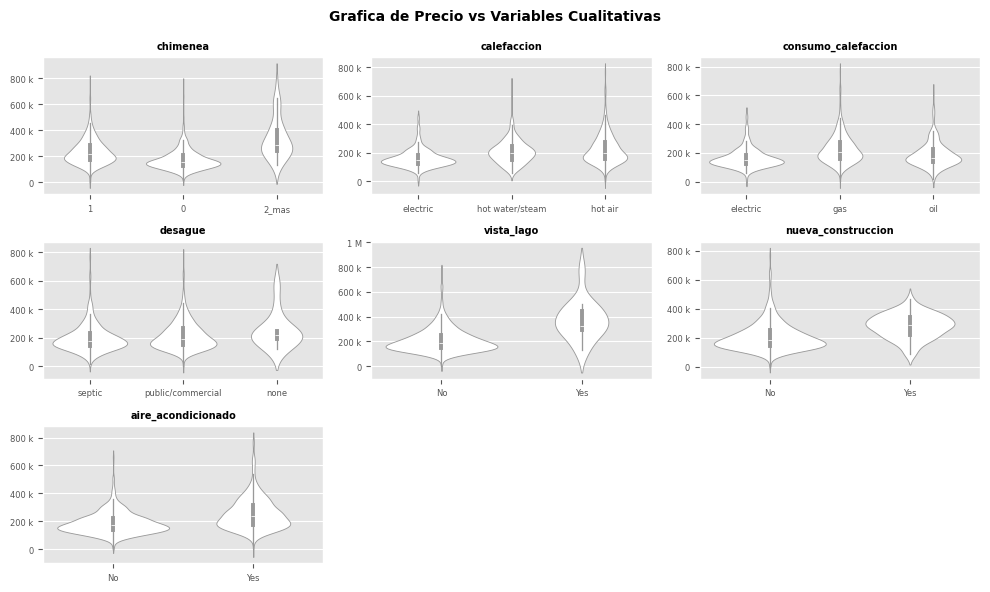

In [33]:
##Grafico relacion entre el precio y las variables cualitativas

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (10,6))
axes = axes.flat
columnas_cualitativas = datos.select_dtypes(include = 'object').columns

for i, columna in enumerate(columnas_cualitativas):
  sns.violinplot(
      data = datos,
      x = columna,
      y = 'precio',
      color = 'white',
      ax = axes[i])

  axes[i].set_title(columna, fontsize = 7, fontweight = 'bold')
  axes[i].tick_params(labelsize = 6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')
  axes[i].yaxis.set_major_formatter(ticker.EngFormatter())

for i in [7,8]:
  fig.delaxes(axes[i])

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Grafica de Precio vs Variables Cualitativas', fontsize = 'medium', fontweight = 'bold')

### Division Train - Test

Evaluar la capacidad predictiva de un modelo consiste en comprobar cómo de proximas son sus predicciones a los verdaderos valores de la variable respuesta. Para poder cuantificarlo de forma correcta, se necesita disponer de un conjunto de observaciones, de las que se conozca la variable respuesta, pero que el modelo "no haya visto", es decir, que no haya participado de su ajuste. Con esta finalidad, se dividen los datos disponibles en un conjunto de entrenamiento y un conjunto de test. El tamaño adecuado de las particiones depende en gran medida de la cantidad de datos disponibles y la seguridad que se necesite en la estimacion del error. Normalmente la proporcion es 80% -20% (suele dar buenos resultados). El reparto debe de hacerse de forma aleatoria o utilizando algun tipo de muestreo probabilistico (estratificado - conglomerado, sistematico)

In [34]:
from re import X
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    datos.drop('precio', axis = 'columns'),
    datos.precio,
    train_size = 0.8,
    test_size = 0.2,
    random_state = 42,
    shuffle = True)

In [35]:
print('Resultado de la Particion de los Datos de Entrenamiento',
      '-------------------------------------------------------',
      y_train.describe(),
      '-------------------------------------------------------',
      sep = '\n')

Resultado de la Particion de los Datos de Entrenamiento
-------------------------------------------------------
count      1382.000000
mean     211229.997829
std       95803.220875
min        5000.000000
25%      145000.000000
50%      190000.000000
75%      256837.500000
max      775000.000000
Name: precio, dtype: float64
-------------------------------------------------------


In [36]:
print('Resultado de la Particion de los Datos de Prueba',
      '-------------------------------------------------------',
      y_test.describe(),
      '-------------------------------------------------------',
      sep = '\n')

Resultado de la Particion de los Datos de Prueba
-------------------------------------------------------
count       346.000000
mean     214909.277457
std      108439.961494
min       64500.000000
25%      148225.000000
50%      185000.000000
75%      260000.000000
max      775000.000000
Name: precio, dtype: float64
-------------------------------------------------------


z = 50000 - 34557.187500	/35021.168056

# Preprocesamiento de Datos
El preprocesado engloba todas aquellas transformaciones realizadas sobre los datos con el objetivo que puedan ser interpretados por el algoritmo de machine learning lo más eficientemente posible. Todo preprocesado de datos debe aprenderse con las observaciones de entrenamiento y luego aplicarse al conjunto de entrenamiento y al de test. Esto es muy importante para no violar la condición de que ninguna información procedente de las observaciones de test participe o influya en el ajuste del modelo. Este principio debe aplicarse también si se emplea validación cruzada. En tal caso, el preprocesado debe realizarse dentro de cada iteración de validación, para que las estimaciones que se hacen con cada partición de validación no contengan información del resto de particiones.

# Imputación de Valores Ausentes o Vacíos

* Eliminar aquellas observaciones que esten incompletas
* Eliminar aquellas variables que esten incompleta
* Tratar de estimar los valores ausentes empleando tecnicas de imputaciones (reemplazar los valores con la media, moda mediana)

# Excluir las variables con varianza proxima o cercana a **CERO**

Se eliminan porque no aportan informacipin a ala variable predictora, ya que el modelo toma solo algunos pocos calores de los cuales con este varianzas aparecen con muy poca frecuencia y tiene poco impacto.

# Estandarizacion y Escalado de Variables Numericas

Cuando los predictores son numéricos, la escala en la que se miden, así como la magnitud de su varianza pueden influir en gran medida en el modelo. Muchos algoritmos de machine learning (SVM, redes neuronales, lasso...) son sensibles a esto, de forma que, si no se igualan de alguna forma los predictores, aquellos que se midan en una escala mayor o que tengan más varianza dominarán el modelo aunque no sean los que más relación tienen con la variable respuesta. Existen principalmente 2 estrategias para evitarlo:

Centrado: consiste en restarle a cada valor la media del predictor al que pertenece. Si los datos están almacenados en un dataframe, el centrado se consigue restándole a cada valor la media de la columna en la que se encuentra. Como resultado de esta transformación, todos los predictores pasan a tener una media de cero, es decir, los valores se centran en torno al origen.
Normalización (estandarización): consiste en transformar los datos de forma que todos los predictores estén aproximadamente en la misma escala. Hay dos formas de lograrlo:
Normalización Z-score : dividir cada predictor entre su desviación típica después de haber sido centrado, de esta forma, los datos pasan a tener una distribución normal.
Estandarización max-min> transformar los datos de forma que estén dentro del rango [0, 1].

# Binarización de las variables cualitativas

Consite en crear nuevas variables "dummy" con cada uno de los niveles de las variables cualitativas. Por ejemplo una variable que extraiga el color (rojo, verde y azul) se convertira a (0,1,2)

In [37]:
#Pipeline / Tuberia de Transformaciones y Preprocesamiento

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Primero vamos a imputar los vacios (no aplica para este dataset pero para tenerlo en el codigo)
#Escalar los datos

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()

preprocesamiento = ColumnTransformer(
    [('scale', StandardScaler(),columnas_numericas),
     ('onehot', OneHotEncoder(handle_unknown='ignore'), columnas_cualitativas)],
    remainder = 'passthrough')

In [38]:
X_train_preprocesado = preprocesamiento.fit_transform(X_train)
X_test_preprocesado = preprocesamiento.transform(X_test)

In [39]:
variables_codificadas = preprocesamiento.named_transformers_['onehot'].get_feature_names_out(columnas_cualitativas)
etiquetas = np.concatenate([columnas_numericas, variables_codificadas])
datos_train_preprocesados = pd.DataFrame(X_train_preprocesado, columns = etiquetas)
datos_test_preprocesados = pd.DataFrame(X_test_preprocesado, columns = etiquetas)

datos_train_preprocesados.head()

,metros_totales,antiguedad,precio_terreno,metros_habitables,universitarios,dormitorios,banios,habitaciones,chimenea_0,chimenea_1,...,consumo_calefaccion_oil,desague_none,desague_public/commercial,desague_septic,vista_lago_No,vista_lago_Yes,nueva_construccion_No,nueva_construccion_Yes,aire_acondicionado_No,aire_acondicionado_Yes
0,0.670540,-0.947542,-0.879312,0.704034,-1.126918,1.031545,0.899822,0.412795,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,-0.495535,-0.279667,-0.533977,-1.352698,-0.153786,-1.415829,-1.365304,-1.744856,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.039488,0.354815,0.003839,0.572889,0.527407,1.031545,-0.610262,0.844325,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.385787,0.154452,0.753951,-0.509854,0.138154,-0.192142,-0.610262,0.412795,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.385787,0.121058,0.385971,-0.770543,0.138154,-0.192142,-0.610262,0.412795,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [40]:
datos_train_preprocesados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   metros_totales                1382 non-null   float64
 1   antiguedad                    1382 non-null   float64
 2   precio_terreno                1382 non-null   float64
 3   metros_habitables             1382 non-null   float64
 4   universitarios                1382 non-null   float64
 5   dormitorios                   1382 non-null   float64
 6   banios                        1382 non-null   float64
 7   habitaciones                  1382 non-null   float64
 8   chimenea_0                    1382 non-null   float64
 9   chimenea_1                    1382 non-null   float64
 10  chimenea_2_mas                1382 non-null   float64
 11  calefaccion_electric          1382 non-null   float64
 12  calefaccion_hot air           1382 non-null   float64
 13  cal

In [41]:
from sklearn.impute import SimpleImputer

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()

transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])


transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])


preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')



In [42]:
X_train_preprocesado = preprocesamiento.fit_transform(X_train)
X_test_preprocesado = preprocesamiento.transform(X_test)

In [43]:
variables_codificadas = preprocesamiento.named_transformers_['cualitativas']['onehot'].get_feature_names_out(columnas_cualitativas)
etiquetas = np.concatenate([columnas_numericas, variables_codificadas])
datos_train_preprocesados = pd.DataFrame(X_train_preprocesado, columns = etiquetas)
datos_test_preprocesados = pd.DataFrame(X_test_preprocesado, columns = etiquetas)

datos_train_preprocesados.head()

,metros_totales,antiguedad,precio_terreno,metros_habitables,universitarios,dormitorios,banios,habitaciones,chimenea_0,chimenea_1,...,consumo_calefaccion_oil,desague_none,desague_public/commercial,desague_septic,vista_lago_No,vista_lago_Yes,nueva_construccion_No,nueva_construccion_Yes,aire_acondicionado_No,aire_acondicionado_Yes
0,0.670540,-0.947542,-0.879312,0.704034,-1.126918,1.031545,0.899822,0.412795,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,-0.495535,-0.279667,-0.533977,-1.352698,-0.153786,-1.415829,-1.365304,-1.744856,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.039488,0.354815,0.003839,0.572889,0.527407,1.031545,-0.610262,0.844325,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.385787,0.154452,0.753951,-0.509854,0.138154,-0.192142,-0.610262,0.412795,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.385787,0.121058,0.385971,-0.770543,0.138154,-0.192142,-0.610262,0.412795,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [44]:
from sklearn import set_config
set_config(display = 'diagram')

preprocesamiento

ColumnTransformer(remainder='passthrough',
                  transformers=[('numericas',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['metros_totales', 'antiguedad',
                                  'precio_terreno', 'metros_habitables',
                                  'universitarios', 'dormitorios', 'banios',
                                  'habitaciones']),
                                ('cualitativas',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['chimenea', 'calefaccion',
                                  'consumo_calefaccion', 'desague',
                                  'vista_lago', 'nueva_construccion',
                                  'aire_acondicionado'])])

## Crear un Modelo

Despues de separar los datos de entrenamiento, estandarizarlos, binarizarlos e imputarlos, debemos de seleccionar el algoritmo que vamos a utilizar

### Entrenamiento

Se adjusta un primer modelo de regresion lineal con regularizacion para predecir el precio de la vivienda en funcion de las variables independientes

In [45]:
from sklearn.linear_model import Ridge

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('modelo', Ridge())
])

#Asignar los resultados _ para que no se imprima la ejecucion en el notebook

_ = pipe.fit(X_train, y_train)

## Validacion

La finalidad de un modelo es predecir la variable respuesta en observaciones futuras o en observaciones en las que el modelo no "ha visto" antes los datos. El error mostrado por defecto tras entrenar el modelo suele ser el error del entrenamiento, ese error que comete el modelo al predecir las observaciones que ya ha habia visto. Si bien estos errores son utiles para entender como esta aprendiendo el modelo (estudio de residuos), no es una estimacion realista de como se comporta el modelo ante nuevas observaciones. (porque la primera vez que se entrena un modelo es demasiado optimista)

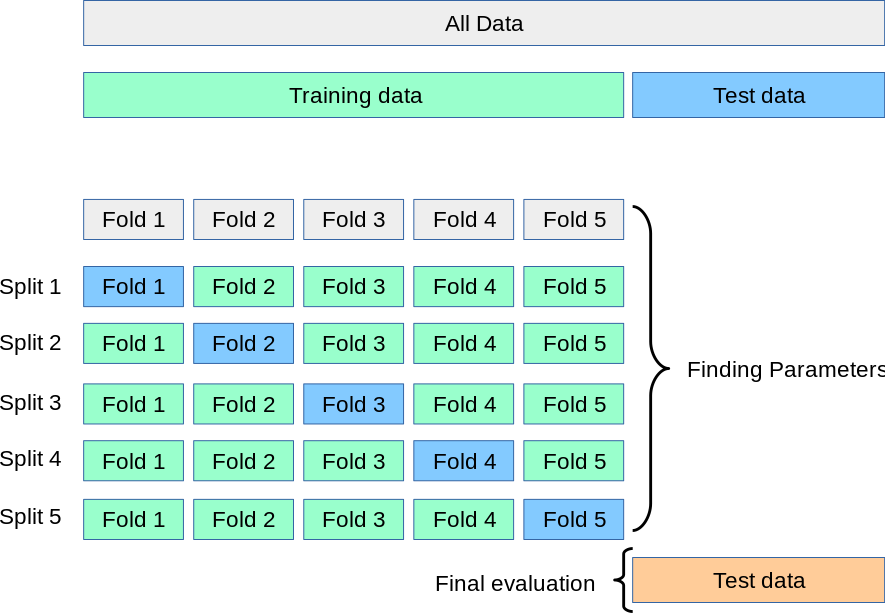

In [46]:
# Validacion Cruzada

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = 5,
    scoring = 'r2'
)


print(f'Metricas de Validacion Cruzada: {cv_scores}')
print(f'Promedio de Metricas: {cv_scores.mean()}', sep = '\n')

Metricas de Validacion Cruzada: [0.64374834 0.62324636 0.62640539 0.73036891 0.62749745]
Promedio de Metricas: 0.6502532907540352


In [47]:
#Validacion Cruzada Repetita

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

cv_scores = cross_val_score(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'r2'
)


print(f'Metricas de Validacion Cruzada: {cv_scores}')
print(f'Promedio de Metricas: {cv_scores.mean()}', sep = '\n')

Metricas de Validacion Cruzada: [0.68113638 0.61715745 0.60195948 0.69879553 0.61162859 0.56105506
 0.69990405 0.66902526 0.67460189 0.66626849 0.64563237 0.61361192
 0.62462236 0.6833389  0.68526573]
Promedio de Metricas: 0.6489335649246996


In [48]:
#Validacion Cruzada con multiples metricas
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

cv_scores = cross_validate(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = ('r2', 'neg_root_mean_squared_error'),
    return_train_score = True
)

#Pasemos los resultados a un dataframe

cv_scores = pd.DataFrame(cv_scores)
cv_scores


,fit_time,score_time,test_r2,train_r2,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
0,0.036271,0.016867,0.681136,0.662275,-54314.647648,-55593.058993
1,0.071100,0.048034,0.617157,0.675286,-55107.897426,-55482.671439
2,0.033907,0.025163,0.601959,0.681574,-60492.529381,-53995.807966
3,0.084933,0.043728,0.698796,0.652337,-58547.618574,-54714.428099
4,0.062829,0.035132,0.611629,0.674866,-55654.786863,-55436.376787
5,0.035196,0.016064,0.561055,0.693656,-66567.534729,-52292.753571
6,0.027230,0.020904,0.699904,0.656258,-53382.532160,-55856.119081
7,0.053171,0.037817,0.669025,0.665634,-54881.227782,-55423.620378
8,0.066368,0.028621,0.674602,0.664357,-57447.599486,-54745.206370
9,0.036869,0.015112,0.666268,0.665391,-48020.445108,-57065.420386


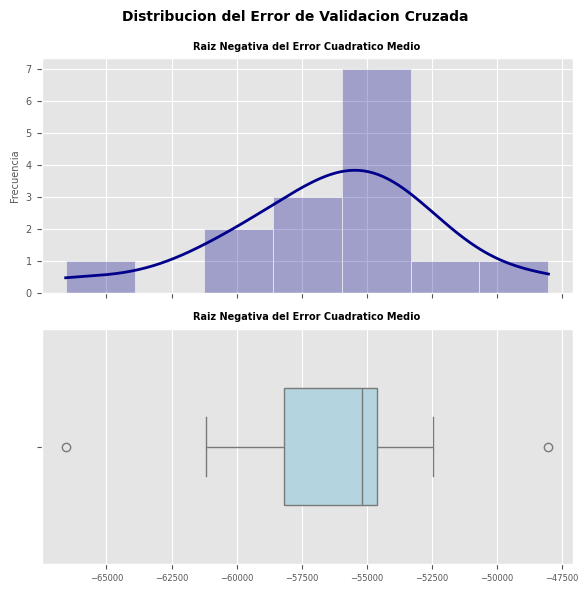

In [49]:
#Distribucion del error de la validacion cruzada

fig, axes = plt.subplots(2, 1, figsize = (6, 6), sharex=True)

sns.histplot(
    data = cv_scores,
    x = 'test_neg_root_mean_squared_error',
    stat = 'count',
    kde = True,
    line_kws = {'linewidth': 2},
    color = 'darkblue',
    alpha = 0.3,
    ax = axes[0]
)

axes[0].set_title('Raiz Negativa del Error Cuadratico Medio', fontsize = 7, fontweight = 'bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frecuencia', fontsize = 7)
axes[0].tick_params(axis = 'both', labelsize = 7)

sns.boxplot(
    data = cv_scores,
    x = 'test_neg_root_mean_squared_error',
    color = 'lightblue',
    width = 0.5,
    ax = axes[1]
)

axes[1].set_title('Raiz Negativa del Error Cuadratico Medio', fontsize = 7, fontweight = 'bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis = 'both', labelsize = 6)

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Distribucion del Error de Validacion Cruzada', fontsize = 10, fontweight = 'bold')
plt.show()

El Cross Val predict en lugar de devolver la metrica de cada particion, lo que nos devuelve son las predicciones de cada particion. Esto se utiliza para poder evaluar los residuos del modelo y diagnosticar el comportamiento

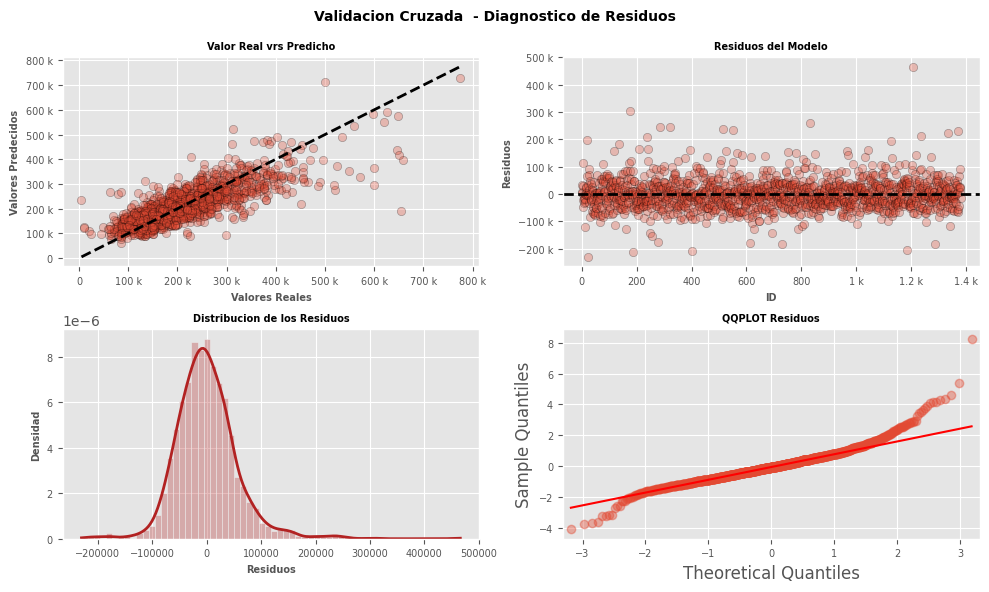

In [50]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold
import statsmodels.api as sm

#Validacion Cruzada

cv = KFold(n_splits = 5, shuffle = True, random_state = 123)

cv_predicciones = cross_val_predict(
    estimator = pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    n_jobs = -1
)

#Graficos Dispersion Real Vrs Predicho

fig, axes = plt.subplots(2, 2, figsize = (10, 6))

axes[0,0].scatter(
    x = y_train,
    y = cv_predicciones,
    alpha = 0.3,
    edgecolors = (0,0,0))

axes[0,0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    color = 'black',
    linewidth = 2,
    linestyle = '--')

axes[0,0].set_xlabel('Valores Reales', fontsize = 7, fontweight = 'bold')
axes[0,0].set_ylabel('Valores Predecidos', fontsize = 7, fontweight = 'bold')
axes[0,0].tick_params(axis = 'both', labelsize = 7)
axes[0,0].set_title('Valor Real vrs Predicho', fontsize = 7, fontweight = 'bold')
axes[0,0].yaxis.set_major_formatter(ticker.EngFormatter())
axes[0,0].xaxis.set_major_formatter(ticker.EngFormatter())


#Graficos Dispersion de Residuos
axes[0,1].scatter(
    x = np.arange(len(y_train)),
    y = y_train - cv_predicciones,
    alpha = 0.3,
    edgecolors = (0,0,0))

axes[0,1].axhline(
    y = 0,
    color = 'black',
    linewidth = 2,
    linestyle = '--')

axes[0,1].set_title('Residuos del Modelo', fontsize = 7, fontweight = 'bold')
axes[0,1].set_xlabel('ID', fontsize = 7, fontweight = 'bold')
axes[0,1].set_ylabel('Residuos', fontsize = 7, fontweight = 'bold')
axes[0,1].tick_params(axis = 'both', labelsize = 7)
axes[0,1].yaxis.set_major_formatter(ticker.EngFormatter())
axes[0,1].xaxis.set_major_formatter(ticker.EngFormatter())

#Distribucion de los Residuos
sns.histplot(
    data = y_train - cv_predicciones,
    stat = 'density',
    kde = True,
    line_kws = {'linewidth': 2},
    color = 'firebrick',
    alpha = 0.3,
    ax = axes[1,0]
)

axes[1,0].set_title('Distribucion de los Residuos', fontsize = 7, fontweight = 'bold')
axes[1,0].set_xlabel('Residuos', fontsize = 7, fontweight = 'bold')
axes[1,0].set_ylabel('Densidad', fontsize = 7, fontweight = 'bold')
axes[1,0].tick_params(axis = 'both', labelsize = 7)

##Grafico QQPLOT
sm.qqplot(
    y_train - cv_predicciones,
    fit = True,
    line = 'q',
    color = 'firebrick',
    alpha = 0.4,
    lw = 2,
    ax = axes[1,1]
)

axes[1,1].set_title('QQPLOT Residuos', fontsize = 7, fontweight = 'bold')
axes[1,1].tick_params(labelsize = 7)

#########
fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Validacion Cruzada  - Diagnostico de Residuos', fontsize = 10, fontweight = 'bold')
plt.show()

In [51]:
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

cv_scores = cross_val_score(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'r2',
    n_jobs = -1 #todos los core disponible
)

print(f'Promedio de Metricas: {cv_scores.mean()}')

Promedio de Metricas: 0.6510234351333708


## Predicciones

Una vez que el modelo ha sido entrenado, directamente por el estimador o por pipeline, utilizamos el metodo final, la punta del iceberg predict() para predecir nuevas observaciones

In [52]:
predicciones = pipe.predict(X_test)

In [53]:
# Se crea un DataFrame con las predicciones y el valor real

df_predicciones = pd.DataFrame(
    data = {'Valor Real': y_test, 'Predicciones': predicciones}
)

df_predicciones.head(10)

,Valor Real,Predicciones
599,240000,311131.374978
1201,775000,436254.357107
628,476000,324429.877399
1498,120000,130120.713788
1263,412500,297408.566236
931,142000,172215.682936
23,150000,204065.852269
844,170000,116580.082787
964,193500,254273.339800
764,150000,138105.393222


## Error del Test

Aunque con el metodo de validacion cruzada se consiguen buenas estimaciones del error que tiene el modelo al predecir, la mejor forma de evaluar un modelo final es prediciendo el conjunto de datos del test, porque este conjunto de observaciones se ha mantenido al margen del proceso de entrenamiento y optimizacion.

### Tecnicas de Precision del Modelo

#### Error Medio Absoluto (MAE)

Es la diferencia entre el valor pronosticado y el valor real en cada punto pronosticado, en promedio.

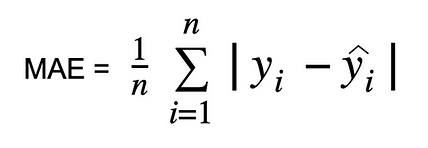

In [54]:
## MAE

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predicciones)

print(mae)

45321.56592159253


### Error Cuadratico Medio (MSE)

Es el error elevando al cuadrado la diferencia entre el valor predicho y el valor real y promediando el conjunto de datos.

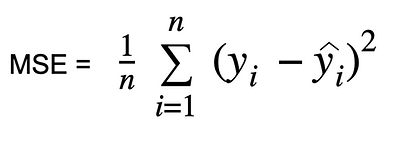

In [55]:
## MSE

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true= y_test, y_pred= predicciones)

print(mse)

4665290617.158833


### Raiz del Error Cuadratico Medio (RMSE)

Mide la magnitud promedio de los errores y se ocupa de las desviaciones del valor real.

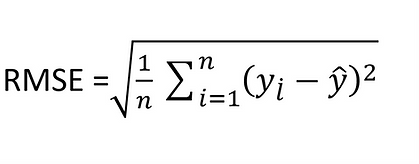

In [56]:
## RMSE

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true= y_test, y_pred= predicciones)

print(np.sqrt(mse))

68302.93271272349


### Coeficiente de Determinacion

 Es una métrica que indica el rendimiento del modelo, nos indica que tanta variación tiene la variable dependiente que se puede predecir desde la variable independiente

 **Consideraciones:**


El valor de R² varía de 0 a 1; los valores más altos indican un ajuste fuerte y los valores más bajos indican un ajuste débil.

* R² < 0,5 → Ajuste débil
* 0,5 ≤ R² ≤ 0,8 → Ajuste moderado
* R² > 0,8 → Ajuste fuerte

Probablemente tengas curiosidad de que significa ¿fuerza de ajuste? Básicamente es en promedio, sus valores predichos no se desvían mucho de sus datos reales.

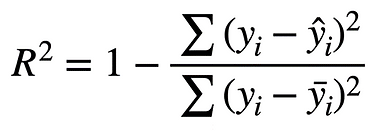

In [57]:
## R2
from sklearn.metrics import r2_score

r2 = r2_score(
    y_true=  y_test,
    y_pred= predicciones)

print(r2)

0.6021155220996928


In [58]:
## R2 Ajustado

n = len(y_test) #Cantidad de Observaciones del test
k = X_test.shape[1] #Cantidad de Variables Independientes

r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(r2_ajustado)


0.5840298640133151


## HiperParametros

Muchos modelos, entre ellos la regresion lineal con Regularizacion Ridge, contiene parametros que no pueden aprenderser apartir de los datos de entrenamiento y por lo tanto deben de ser establecidos por el analista o cientifico de datos. A esto se le conoce como los hiperparametros. Los resultados de un modelo pueden depender en gran medida del valor que tomen sus hiperparametros, sin embargo, no se pueden conocer de antemano cual es el adecuado, entonces con la practica, nosotros los especialistas en machine learning ganamos intuicion y conocimiento sobre que valores pueden funcionar para mejorar el problema; **No hay reglas fijas**. La forma comun de encontrar los valores optimos es probando diferentes posibilidades.

1. Escoger un conjunto de valores para los hiperparametros (Expertos)
2. **GridSearch:** Hace una busqueda exhaustiva sobre un conjunto de valores previamente definida por el analista.
3. **RandomSearch:** Se evaluan valores aleatorios dentre de unos limites definidos por el analista.

    * Para cada valor, entrenar el modelo y estimar su error mediante alguno metodo de validacion.
    * Ajustar nuevamente el modelo, esta vez con todos los datos de entrenamiento y sus mejores hiperparametros.



In [59]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('modelo', Ridge())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'modelo__alpha':np.logspace(-5,3,10)}

grid = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0
)

grid

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=123),
             estimator=Pipeline(steps=[('preprocesamiento',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('numericas',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['metros_totales',
                                                                          'antiguedad',
                                                                          'precio_terreno',
                                                                          'metros_habitables',
                                                                          'univ...
                                                                          'calefaccion',
                                                                          'consumo_calefaccion',
                                                                          'desague',
                                                                          'vista_lago',
                                                                          'nueva_construccion',
                                                                          'aire_acondicionado'])])),
                                       ('modelo', Ridge())]),
             n_jobs=1,
             param_grid={'modelo__alpha': array([1.00000000e-05, 7.74263683e-05, 5.99484250e-04, 4.64158883e-03,
       3.59381366e-02, 2.78255940e-01, 2.15443469e+00, 1.66810054e+01,
       1.29154967e+02, 1.00000000e+03])},
             return_train_score=True, scoring='r2')

In [60]:
#Asignar el resultado a los datos de entrenamiento

_ = grid.fit(X_train, y_train)

In [61]:
# Resultado del Grid

resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)

,param_modelo__alpha,mean_test_score,std_test_score,mean_train_score,std_train_score
7,16.681005,0.651509,0.039267,0.665617,0.009566
6,2.154435,0.651508,0.042932,0.668849,0.009922
5,0.278256,0.650806,0.044123,0.668998,0.009941
4,0.035938,0.650681,0.044305,0.669001,0.009942
3,0.004642,0.650665,0.044329,0.669001,0.009942
2,0.000599,0.650663,0.044332,0.669001,0.009942
1,0.000077,0.650662,0.044333,0.669001,0.009942
0,0.000010,0.650662,0.044333,0.669001,0.009942
8,129.154967,0.641686,0.037092,0.650881,0.009047
9,1000.000000,0.586504,0.034224,0.590802,0.008243


In [62]:
# Mejores HiperParametros

print('-----------',
      'Mejores Parametros Encontrados',
      grid.best_params_, grid.best_score_,grid.scoring, sep = '\n')

-----------
Mejores Parametros Encontrados
{'modelo__alpha': 16.681005372000556}
0.6515091036208346
r2


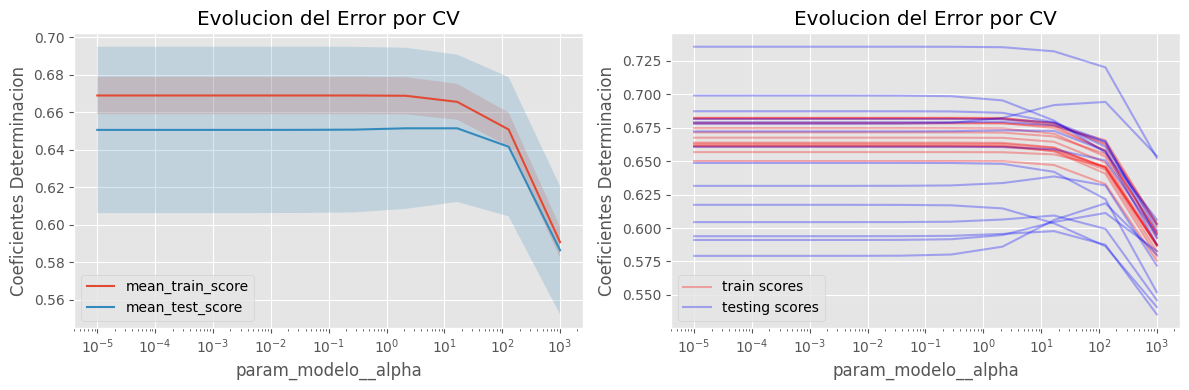

In [63]:
#Graficar los resultados de validacion cruzada

#Grafico 1

fig, axes = plt.subplots(nrows = 1, ncols =2, figsize = (12,4))

resultados.plot('param_modelo__alpha', 'mean_train_score', ax = axes[0])
resultados.plot('param_modelo__alpha', 'mean_test_score', ax = axes[0])

axes[0].fill_between(resultados.param_modelo__alpha.astype(np.float64),
                     resultados['mean_train_score'] + resultados['std_train_score'],
                     resultados['mean_train_score'] - resultados['std_train_score'], alpha = 0.2)
axes[0].fill_between(resultados.param_modelo__alpha.astype(np.float64),
                     resultados['mean_test_score'] + resultados['std_test_score'],
                     resultados['mean_test_score'] - resultados['std_test_score'], alpha = 0.2)

axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_title('Evolucion del Error por CV')
axes[0].set_ylabel('Coeficientes Determinacion')


#Grafico 2

numero_splits = grid.n_splits_

resultados.plot('param_modelo__alpha', [f'split{i}_train_score' for i in range(numero_splits)], alpha = 0.3, c = 'red', ax = axes[1])
resultados.plot('param_modelo__alpha', [f'split{i}_test_score' for i in range(numero_splits)], alpha = 0.3, c = 'blue', ax = axes[1])

axes[1].legend(
    (axes[1].get_children()[1], axes[1].get_children()[numero_splits]),
    ('train scores','testing scores'))


axes[1].set_xscale('log')
axes[1].set_title('Evolucion del Error por CV')
axes[1].set_ylabel('Coeficientes Determinacion')

fig.tight_layout()

### Grid Search

Hace una busqueda exhaustiva evaluando todas las combinaciones de parametros posibles. Su principal desventaja es que invierte mucho tiempo en regiones de poco interes antes de evaluar otras combinaciones

## Random Search

Hace una busqueda aleatoria de los parametros en un rango brindado

In [64]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'modelo__alpha':np.logspace(-5,3,100)}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__alpha,mean_test_score,std_test_score,mean_train_score,std_train_score
43,7.924829,0.652101,0.040757,0.667712,0.009783


## Optimizacion Bayesiana

Las 3 estrategias que hemos utilizando anteriormente son totalmente validas y generan buenos resultados, sobretodo cuando se tiene criterio para acotar el rango de busqueda, pero todo lo anterior realizado comparte una debilidad: ninguna tiene en cuenta los resultados obtenidos hasta el momento, lo que les impide focalizar la busqueda en regiones de mayor interes y evitar las regiones innecesarias.

Una alternativa es la busquedad de HiperParametros con metodos de optimizacion bayesiana. En terminos generales, consiste en crear un modelo probabilistico en el que la funcion objetivo es la metrica de validacion del modelo (RMSE, R2 , AUC / ROC, precision). El objetivo final es reducir el numero de combinaciones de hiperparametros con las que se evalua el modelo, eligiendo unicamente los mejores resultados.

Esto significa que, la ventaja a las otras estrategias utilizadas previamente son superiores ya que maximiza el espacio de busqueda.

In [65]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.7 MB/s eta 0:00:00


In [66]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from skopt.plots import plot_convergence

espacio_busqueda =  [Real(1e-5, 1e+3,'log-uniform',name = 'modelo__alpha')]

@use_named_args(espacio_busqueda)
def objetivo(**params):
    pipe.set_params(**params)
    return -np.mean(cross_val_score(pipe, X_train, y_train, cv = 5, n_jobs = -1,
                                    scoring = 'neg_root_mean_squared_error'))

resultado_opt = gp_minimize(
    func = objetivo,
    dimensions = espacio_busqueda,
    n_calls = 50,
    random_state = 0,
    n_jobs = -1)

print(f'Mejor Score Validacion:{resultado_opt.fun}')
print(f'Mejores Hiperparametros:{list(zip([x.name for x in espacio_busqueda], resultado_opt.x))}')

Mejor Score Validacion:56342.51518849803
Mejores Hiperparametros:[('modelo__alpha', 5.831935834230112)]


<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

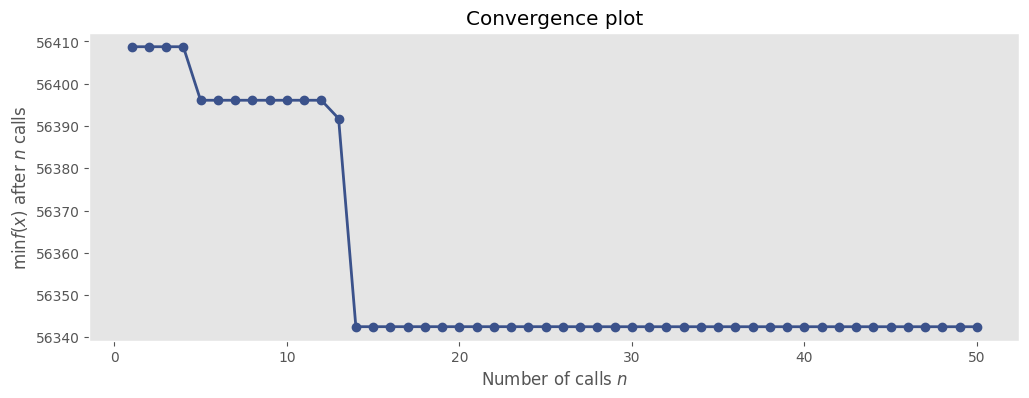

In [67]:
#Evolucion del errorr

fig,ax = plt.subplots(figsize = (12,4))
plot_convergence(resultado_opt, ax = ax)

## Tuning del Preprocesado

En la mayoria de los casos, el proceso de optimizacion se centra en los hiperpametros del modelo. Sin embargo, tambien puede ser muy util e interesante comparar diferentes transformaciones del preprocesado


In [68]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', Ridge())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
    'modelo__alpha':np.logspace(-5,3,10)}

grid = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0
)

grid.fit(X_train, y_train)

# Resultados del Grid

resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False).head(1)

,param_interaciones,param_modelo__alpha,mean_test_score,std_test_score,mean_train_score,std_train_score
17,passthrough,16.681005,0.651509,0.039267,0.665617,0.009566


## Algoritmos

### K-Nearest Neighbor (K Vecinos Mas Cercanos)

Su funcionamiento es el siguiente: para predecir una observación se identifican las K observaciones del conjunto de entrenamiento que más se asemejan a ella (en base a sus predictores) y se emplea como valor predicho el promedio de la variable respuesta en dichas observaciones.

Dada su sencillez, suele dar peores resultados que otros algoritmos, pero es buen referente de base.

##### **Ventajas:**

Es facil de usar e implementar dada su sencillez.

##### **Desventaja:**

El dataset que utiliza para entrenar "cada punto" requiere el uso de memoria excesiva y muchos recursos (CPU) para el procesamiento.

Por ende este modelo tiende funcionar mejor en dataset pequeños y sin una cantidad grande de caracteristicas (pocas columnas).

## Como funciona KNN?

1.	Calcular la distancia entre el item a clasificar y el resto de items del dataset de entrenamiento.
2.	Seleccionar los “k” elementos más cercanos (con menor distancia, según la función que se use)
3.	Realizar una “votación de mayoría” entre los k puntos: los de una clase/etiqueta que <<dominen>> decidirán su clasificación final.

Teniendo en cuenta el punto 3, veremos que para decidir la clase de un punto es muy importante el valor de k, pues este terminará casi por definir a qué grupo pertenecerán los puntos, sobre todo en las “fronteras” entre grupos. Por ejemplo -y a priori- yo elegiría valores impares de k para desempatar (si las features que utilizamos son pares). No será lo mismo tomar para decidir 3 valores que 13. Esto no quiere decir que necesariamente tomar más puntos implique mejorar la precisión. Lo que es seguro es que cuantos más “puntos k”, más tardará nuestro algoritmo en procesar y darnos respuesta.

Las formas más populares de “medir la cercanía” entre puntos son la distancia Euclidiana (la “de siempre”) o la Cosine Similarity (mide el ángulo de  los vectores, cuanto menores, serán similares). Recordemos que este algoritmo -y prácticamente todos en ML- funcionan mejor con varias características de las que tomemos datos (las columnas de nuestro dataset). Lo que entendemos como “distancia” en la vida real, quedará abstracto a muchas dimensiones que no podemos “visualizar” fácilmente (como por ejemplo en un mapa).


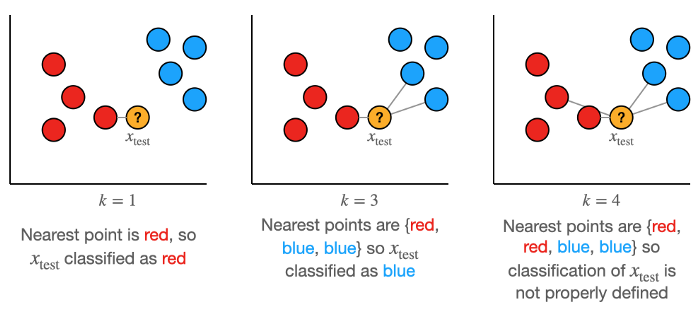

In [69]:
from sklearn.neighbors import KNeighborsRegressor

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('modelo', KNeighborsRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'modelo__n_neighbors':np.linspace(1,100,500, dtype=int)}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__n_neighbors,mean_test_score,std_test_score,mean_train_score,std_train_score
47,11,0.606722,0.032467,0.675183,0.007877


In [70]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_knn = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_knn}')

El Error r2 del test es: 0.5923519074748773


### Modelo Lineal Ridge



In [71]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', Ridge())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
    'modelo__alpha':np.logspace(-5,3,10)}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__alpha,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
17,16.681005,passthrough,0.651509,0.039267,0.665617,0.009566


In [72]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_ridge = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_ridge}')

El Error r2 del test es: 0.5987203402053218


## Arboles de Decision

Los árboles de decisión son modelos predictivos formados por reglas binarias (si/no) con las que se consigue repartir las observaciones en función de sus atributos y predecir así el valor de la variable respuesta.
Muchos métodos predictivos generan modelos globales en los que una única ecuación se aplica a todo el espacio muestral. Cuando el caso de uso implica múltiples predictores, que interaccionan entre ellos de forma compleja y no lineal, es muy difícil encontrar un único modelo global que sea capaz de reflejar la relación entre las variables. Los métodos estadísticos y de machine learning basados en árboles engloban a un conjunto de técnicas supervisadas no paramétricas que consiguen segmentar el espacio de los predictores en regiones simples, dentro de las cuales es más sencillo manejar las interacciones. Es esta característica la que les proporciona gran parte de su potencial.

### Arboles de Decision para Regresion
Los arboles de regresion son el subtipo de arboles de prediccion que se aplica cuando la variable respuesta es continua. En terminos generales, en el entrenamiento de un arbol de regresion, las observaciones se van distribuyendo por bifurcaciones (nodos) generando una estructura del arbol hasta alcanzar uno de los nodos terminales (respuesta). La prediccion del arbol es la media de la variable respuesta de las observaciones que estan en ese mismo nodo terminal.


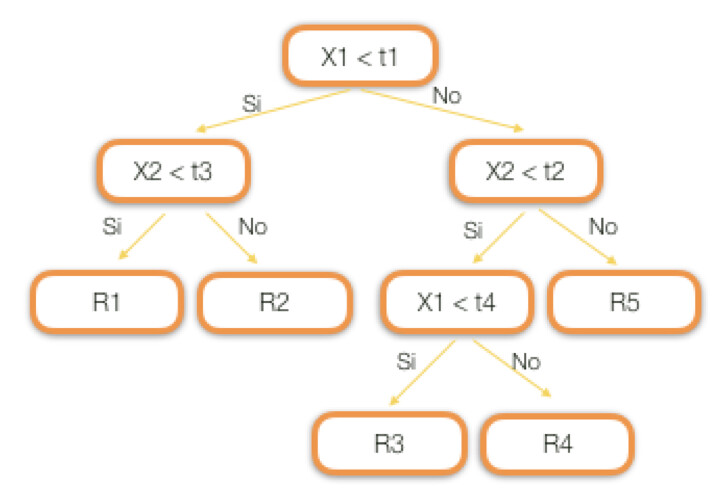

In [73]:
from sklearn.tree import DecisionTreeRegressor


columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', DecisionTreeRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
              'modelo__max_depth':[None,3,5,10,20],
              'modelo__min_samples_split': [2,5,10],
              'modelo__max_features':['auto','sqrt','log2',None]}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    random_state = 123,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__min_samples_split,param_modelo__max_features,param_modelo__max_depth,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
18,5,None,5,passthrough,0.530813,0.071883,0.73021,0.007675


In [74]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_decision = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_decision}')

El Error r2 del test es: 0.49835300381315606


## Random Forest

In [75]:
from sklearn.ensemble import RandomForestRegressor


columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', RandomForestRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
              'modelo__n_estimators':[10,50,100,200,1000,1500],
              'modelo__max_depth':[None,3,5,10,20],
              'modelo__min_samples_split': [2,5,10,20],
              'modelo__max_features':['auto','sqrt','log2',None]}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 3, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    random_state = 123,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__n_estimators,param_modelo__min_samples_split,param_modelo__max_features,param_modelo__max_depth,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
5,1500,10,sqrt,20,PolynomialFeatures(),0.676014,0.030146,0.889969,0.006709


In [76]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_rf = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_rf}')

El Error r2 del test es: 0.6476396456115388


## Gradient Boosting

Esta formado por un conjunto de arboles de decision individuales, entrenados de forma secuencial, de forma que cada arbol nuevo trata de mejorar los errores de los arboles anteriores. La prediccion de una nueva observacion se obtiene agregando las predicciones de todos los arboles individules que forman el modelo.

### Gradient Boosting Tree

  1. LightGBM
    * Permite que las observaciones incluyan valares vacios
    * Permite el uso de GPUs
    * Entrenamiento paralelizado (paraleliza alguna partes del algoritmo)
    * No es necesario one-hot-encoding de variables categoricas
    * Permite trabajar sobre matrices sparse
    * Permite restricciones monotonicas

  2. XGBoost
    * Permite que las observaciones incluyan valares vacios
    * Permite el uso de GPUs
    * Entrenamiento paralelizado (paraleliza alguna partes del algoritmo)
    * No es necesario one-hot-encoding de variables categoricas
    * Permite trabajar sobre matrices sparse
    * Permite restricciones monotonicas

  3. CATBoost
    * Optimizado principalmente para variables categoricas
    * Utiliza arboles simetricos
    *  Permite que las observaciones incluyan valares vacios
    * Permite el uso de GPUs
    * Entrenamiento paralelizado (paraleliza alguna partes del algoritmo)
    * Permite restricciones monotonicas

  4. H2O
    * Si realiza binning
    * Multicore (paraleliza algunas partes del algoritmo)
    * Permite restricciones monotonicas
    * Permite que las observaciones incluyan valares vacios
    * No es necesario one-hot-encoding de variables categoricas

Existen tipos ensemble y entre ellos los mas utilizados son:

* **Bagging:**  Se ajustan multiples modelos, cada uno con un subconjunto distinto de datos entrenamiento. Para predecir, todos los modelos que forman el agregado participan aportando una prediccion. Tomamos la media de todas las predicciones (variables continuas), o la clase mas frecuente (variables categoricas). Random Forest

* **Boosting:** Se ajustan secuencialmente multiples modelo sencillos, de forma que cada modelo aprende de los errores del anterior. Grandiet Booting Trees.

In [77]:
from sklearn.ensemble import GradientBoostingRegressor


columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', GradientBoostingRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
              'modelo__n_estimators':[50,100,200,1000,2000],
              'modelo__max_depth':[None,3,5,10,20],
              'modelo__min_samples_split': [2,5,10,20],
              'modelo__max_features':['auto','sqrt','log2',None],
              'modelo__subsample':[0.5, 0.7,1]}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 3, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    random_state = 123,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__subsample,param_modelo__n_estimators,param_modelo__min_samples_split,param_modelo__max_features,param_modelo__max_depth,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
35,1.0,1000,2,sqrt,5,passthrough,0.691199,0.027862,0.999715,0.00007


In [78]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_gradient = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_gradient}')

El Error r2 del test es: 0.6785406576993307


## Stacking

A modo general, el término model ensembling hace referencia a la combinación de las predicciones de dos o más modelos distintos con el objetivo de mejorar las predicciones finales. Esta estrategia se basa en la asunción de que, distintos modelos entrenados independientemente, emplean distintos aspectos de los datos para realizar las predicciones, es decir, cada uno es capaz de identificar parte de la “verdad” pero no toda ella. Combinando la perspectiva de cada uno de ellos, se obtiene una descripción más detallada de la verdadera estructura subyacente en los datos. A modo de analogía, imagínese un grupo de estudiantes que se enfrentan a un examen multidisciplinal. Aunque todos obtengan aproximadamente la misma nota, cada uno de ellos habrá conseguido más puntos con las preguntas que tratan sobre las disciplinas en las que destacan. Si en lugar de hacer el examen de forma individual, lo hacen en grupo, cada uno podrá contribuir en los aspectos que más domina, y el resultado final será probablemente superior a cualquiera de los resultados individuales.

La clave para que el ensembling consiga mejorar los resultados es la diversidad de los modelos. Si todos los modelos combinados son similares entre ellos, no podrán compensarse unos a otros. Por esta razón, se tiene que intentar combinar modelos que sean lo mejor posible a nivel individual y lo más diferentes entre ellos.

## Algoritmo Super Learner

Emplea un nuevo modelo para que decida la mejor forma de combinar las predicciones de los otros modelos.

  1. **Definicion del ensemble:**
    * Definir un listado con los algoritmos base (cada uno con los hiperparametros pertinentes)
    * Seleccionar el algoritmo de metalearning que defina como se entrena en modelo superior. Por defecto, se emplea RidgeCV para regresion, LogisticRegression para clasificacion.

  2. **Entrenamiento de Ensemble:**
    * Entrenar cada uno de los algoritmos base con el conjunto de entrenamiento.
    * Realizar K-fold cross-validation con cada uno de los algoritmos base y almacena las predicciones hechas en cada una de las k-particiones.
    * Combinar las predicciones del paso 2 en una unica matriz NxL (N=Numero de observaciones del conjunto de entrenamiento, L= Numero de modelos base)
    * Entrenar el metalearning con la variable respuesta y la matriz NxL como predictores.
    * El Super Learner final esta formado por los modelos base y el modelo metalearning.

  3. **Predecir**
    * Predecir la nueva observacion con cada uno de los modelos base
    * Emplear las predicciones de los modelos como input del metalearner para obtener la prediccion final.

In [79]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

pipe_ridge = Pipeline(
    [('preprocesamiento', preprocesamiento),
     ('ridge', Ridge(alpha = 16.7))])

pipe_knn = Pipeline(
    [('preprocesamiento', preprocesamiento),
     ('knn', KNeighborsRegressor(n_neighbors = 10))])

pipe_rf = Pipeline(
    [('preprocesamiento', preprocesamiento),
     ('random_forest', RandomForestRegressor(n_estimators = 200, max_depth = 20, min_samples_split = 5, max_features = 'sqrt'))])

In [80]:
# Definir y entrenar el StackingRegresor

stacking_regresor = StackingRegressor(
    estimators = [('ridge', pipe_ridge),
                  ('knn', pipe_knn),
                  ('random_forest', pipe_rf)],
    final_estimator = RidgeCV())

_=stacking_regresor.fit(X_train, y_train)

In [81]:
#Error del test final

modelo_final =  stacking_regresor
predicciones = modelo_final.predict(X_test)
r2_stacking = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_stacking}')

El Error r2 del test es: 0.6493633244080783


# Comparacion de los eventos

Como paso final comparamos el error del modelo

In [82]:
error_modelos = pd.DataFrame({
    'modelo':['knn','lm','random forest','gradient boosting', 'stacking'],
    'r2': [r2_knn, r2_ridge, r2_decision,r2_rf, r2_gradient, r2_stacking]})

error_modelos = error_modelos.sort_values('r2', ascending = False)

fig, ax = plt.subplots(figsize = (6,4))

ax.hlines(error_modelos.modelo, xmin= 0, xmax = error_modelos.r2)
ax.plot(error_modelos.r2, error_modelos.modelo, 'o', color = 'black')
ax.tick_params(axis = 'y', which = 'major', labelsize = 12)
ax.set_title('Comparacion de error de test de los modelos')
ax.set_xlabel('Test R2')

ValueError: All arrays must be of the same length

# Aplicando nuestro modelo a un conjunto de Datos Nuevos

In [ ]:
datos_nuevos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/SaratogaHouses_nuevo.csv', sep = ';')

datos_nuevos.columns = ['metros_totales','antiguedad','precio_terreno','metros_habitables','universitarios','dormitorios',
                 'chimenea','banios','habitaciones','calefaccion','consumo_calefaccion','desague','vistas_lago',
                 'nueva_construccion','aire_acondicionado']


datos_nuevos

In [ ]:
nuevas_predicciones = stacking_regressor.predict(datos_nuevos)
nuevas_predicciones

In [ ]:
# Añadir las predicciones al conjunto de datos nuevo

datos_nuevos.insert(0,"Prediccion Precio", nuevas_predicciones, allow_duplicates="False")

datos_nuevos